<a href="https://colab.research.google.com/github/ankan-git-coder/Deep-learning-COURSE/blob/main/VISION_TRANSFORMER_PYTORCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

# --------------------------------------------------
batch_size = 64
num_classes = 10
image_size = 28
patch_size = 4
num_channels = 1

# Calculate updated token count (28 // 4) ** 2 = 49 patches
patch_num = int((image_size // patch_size) ** 2)


embed_dim = 64
attention_heads = 4
transformer_blocks = 6
mlp_nodes = 256
dropout_prob = 0.1

epochs = 10
learning_rate = 5e-4
weight_decay = 1e-4

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_data = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_data = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [86]:
class PatchEmbedding(nn.Module):
    def __init__(self, num_channels, patch_size, embed_dim):
        super().__init__()
        self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2) # Shape: (B, patch_num, embed_dim)
        return self.dropout(x)

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, attention_heads, mlp_nodes):
        super().__init__()
        self.layer_nom1 = nn.LayerNorm(embed_dim)
        self.multi_head_attention = nn.MultiheadAttention(embed_dim, attention_heads, batch_first=True, dropout=dropout_prob)

        self.layer_nom2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_nodes),
            nn.GELU(),
            nn.Dropout(dropout_prob),
            nn.Linear(mlp_nodes, embed_dim),
            nn.Dropout(dropout_prob)
        )

    def forward(self, x):
        # Attention Path
        residual_1 = x
        x = self.layer_nom1(x)
        x, _ = self.multi_head_attention(x, x, x)
        x = x + residual_1

        # MLP Feedforward Path
        residual_2 = x
        x = self.layer_nom2(x)
        x = self.mlp(x)
        x = x + residual_2
        return x

class MLPHead(nn.Module):
    def __init__(self, embed_dim, num_classes):
        super().__init__()
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = x[:, 0, :] # Extract only the [CLS] token
        x = self.layer_norm(x)
        x = self.mlp_head(x)
        return x

In [87]:
class VisionTransformer(nn.Module):
    def __init__(self, num_channels, patch_size, embed_dim, patch_num, attention_heads, transformer_blocks, mlp_nodes, num_classes):
        super().__init__()
        self.patch_embedding = PatchEmbedding(num_channels, patch_size, embed_dim)

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.position_embedding = nn.Parameter(torch.randn(1, patch_num + 1, embed_dim))
        self.dropout = nn.Dropout(dropout_prob)

        self.transformer_blocks = nn.Sequential(*[
            TransformerEncoder(embed_dim, attention_heads, mlp_nodes) for _ in range(transformer_blocks)
        ])

        self.mlp_head = MLPHead(embed_dim, num_classes)

    def forward(self, x):
        b = x.shape[0]
        x = self.patch_embedding(x)

        cls_tokens = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.position_embedding
        x = self.dropout(x)

        x = self.transformer_blocks(x)
        return self.mlp_head(x)

model = VisionTransformer(num_channels, patch_size, embed_dim, patch_num, attention_heads, transformer_blocks, mlp_nodes, num_classes).to(device)


optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

In [88]:
for epoch in range(epochs):
    model.train()
    correct_images, total_images = 0, 0
    running_loss = 0.0

    for images, labels in train_data:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        predictions = outputs.argmax(dim=1)
        correct_images += (predictions == labels).sum().item()
        total_images += labels.size(0)
        running_loss += loss.item() * images.size(0)

    train_accuracy = (correct_images / total_images) * 100
    epoch_loss = running_loss / total_images
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Train Accuracy: {train_accuracy:.2f}%")


model.eval()
val_correct, val_total = 0, 0
with torch.no_grad():
    for images, labels in val_data:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        val_correct += (predictions == labels).sum().item()
        val_total += labels.size(0)

val_accuracy = (val_correct / val_total) * 100
print(f"\n🚀 Highly Accurate Final Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/10] - Loss: 0.5739 - Train Accuracy: 81.46%
Epoch [2/10] - Loss: 0.2073 - Train Accuracy: 93.66%
Epoch [3/10] - Loss: 0.1522 - Train Accuracy: 95.34%
Epoch [4/10] - Loss: 0.1262 - Train Accuracy: 96.06%
Epoch [5/10] - Loss: 0.1077 - Train Accuracy: 96.67%
Epoch [6/10] - Loss: 0.0928 - Train Accuracy: 97.02%
Epoch [7/10] - Loss: 0.0862 - Train Accuracy: 97.23%
Epoch [8/10] - Loss: 0.0756 - Train Accuracy: 97.62%
Epoch [9/10] - Loss: 0.0706 - Train Accuracy: 97.78%
Epoch [10/10] - Loss: 0.0660 - Train Accuracy: 97.95%

🚀 Highly Accurate Final Validation Accuracy: 98.23%


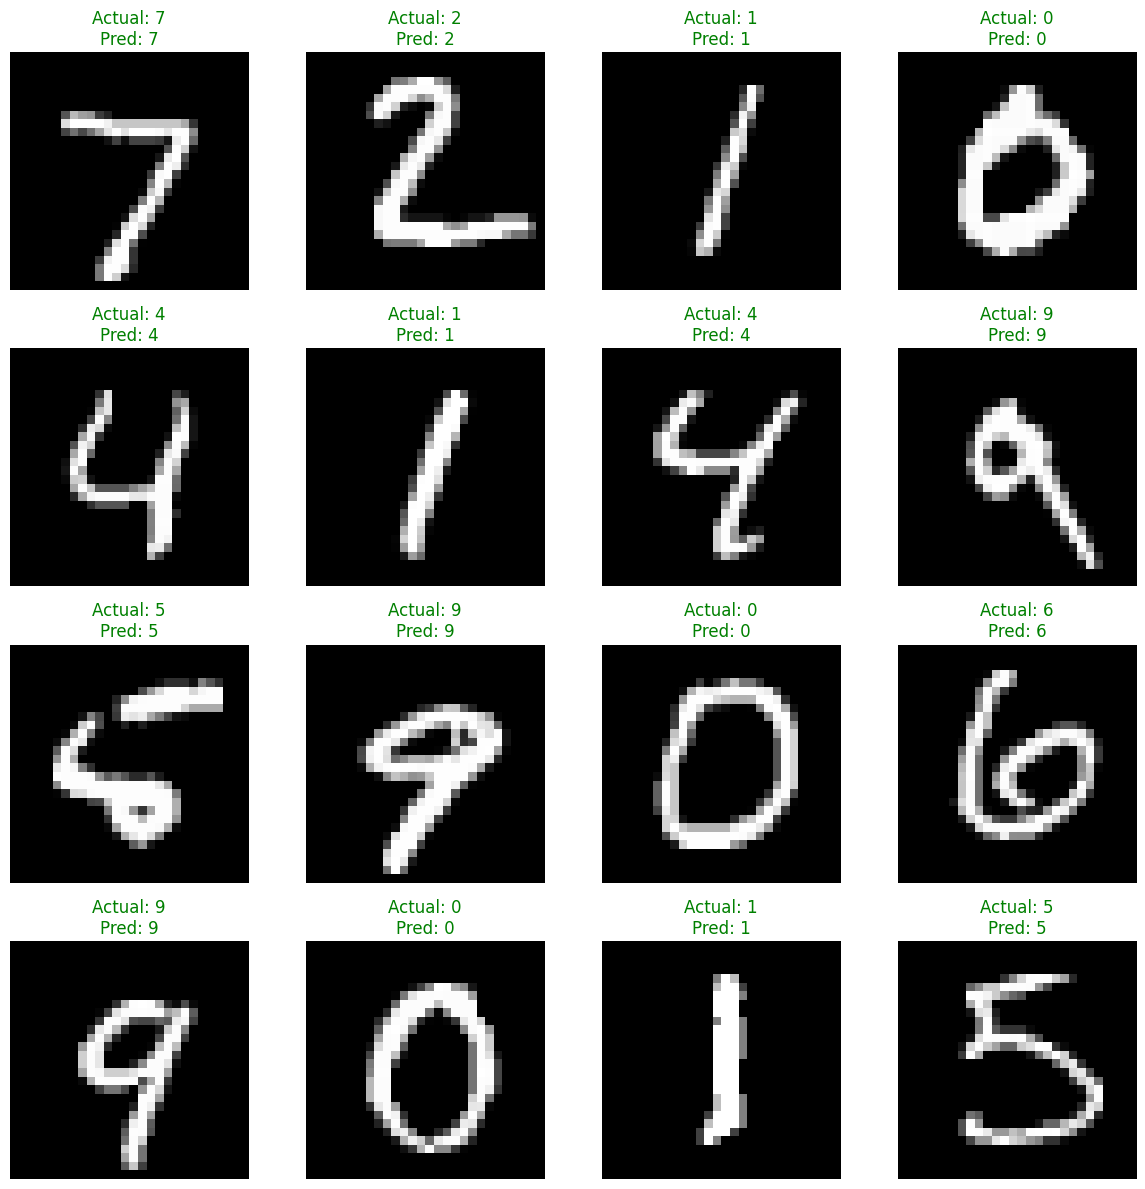

In [90]:
import matplotlib.pyplot as plt
import numpy as np


model.eval()


images, labels = next(iter(val_data))


images_dev, labels_dev = images.to(device), labels.to(device)
with torch.no_grad():
    outputs = model(images_dev)
    predictions = outputs.argmax(dim=1)


images = images.cpu()
labels = labels.cpu().numpy()
predictions = predictions.cpu().numpy()


fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(16):
    img = images[i].squeeze().numpy()
    img = (img * 0.3081) + 0.1307
    img = np.clip(img, 0, 1)



    color = 'green' if predictions[i] == labels[i] else 'red'


    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Actual: {labels[i]}\nPred: {predictions[i]}", color=color, fontsize=12)

plt.tight_layout()
plt.show()